In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Online Shoppers Purchasing Intention dataset

shoppers_df = pd.read_csv("online_shoppers_intention.csv")

print("Dataset loaded successfully.")
print("Shape:", shoppers_df.shape)

Dataset loaded successfully.
Shape: (12330, 18)


In [3]:
# Display the first five rows

shoppers_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Display column names and data types

shoppers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
# Check for missing values

shoppers_df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
# Check the distribution of the target variable

print("Revenue distribution:")
print(shoppers_df["Revenue"].value_counts())

print("\nRevenue percentage:")
print(shoppers_df["Revenue"].value_counts(normalize=True) * 100)

Revenue distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Revenue percentage:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


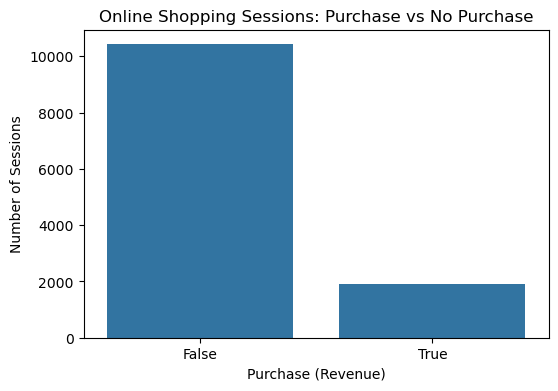

In [7]:
# Visualise the target distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=shoppers_df, x="Revenue")
plt.title("Online Shopping Sessions: Purchase vs No Purchase")
plt.xlabel("Purchase (Revenue)")
plt.ylabel("Number of Sessions")
plt.show()

In [8]:
# Identify categorical and numerical columns

categorical_cols = shoppers_df.select_dtypes(include=["object", "bool"]).columns.tolist()
numerical_cols = shoppers_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Numerical columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


In [9]:
# Check unique values in categorical variables

for col in categorical_cols:
    print(f"\n{col}:")
    print(shoppers_df[col].value_counts())


Month:
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

VisitorType:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

Weekend:
Weekend
False    9462
True     2868
Name: count, dtype: int64

Revenue:
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [10]:
# Summary statistics for numerical variables

shoppers_df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [11]:
# Separate predictor variables (X) and target variable (y)

X = shoppers_df.drop("Revenue", axis=1)
y = shoppers_df["Revenue"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12330, 17)
y shape: (12330,)


In [12]:
# Convert categorical variables into numerical dummy variables

X = pd.get_dummies(
    X,
    columns=["Month", "VisitorType"],
    drop_first=True
)

print("Encoded X shape:", X.shape)
print("\nData types after encoding:")
print(X.dtypes.value_counts())

Encoded X shape: (12330, 26)

Data types after encoding:
bool       12
int64       7
float64     7
Name: count, dtype: int64


In [13]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (9864, 26)
Testing set: (2466, 26)

Training target distribution:
Revenue
False    0.845296
True     0.154704
Name: proportion, dtype: float64

Testing target distribution:
Revenue
False    0.845093
True     0.154907
Name: proportion, dtype: float64


In [14]:
# Train a Decision Tree classifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [15]:
# Evaluate the Decision Tree

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("-" * 30)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")

Decision Tree Performance
------------------------------
Accuracy : 0.8646
Precision: 0.5645
Recall   : 0.5497
F1-score : 0.5570
ROC-AUC  : 0.7360


In [16]:
# Detailed classification report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       False       0.92      0.92      0.92      2084
        True       0.56      0.55      0.56       382

    accuracy                           0.86      2466
   macro avg       0.74      0.74      0.74      2466
weighted avg       0.86      0.86      0.86      2466



In [17]:
# Train a Random Forest classifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [18]:
# Evaluate the Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-" * 30)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
------------------------------
Accuracy : 0.8990
Precision: 0.7333
Recall   : 0.5471
F1-score : 0.6267
ROC-AUC  : 0.9184


In [19]:
# Detailed classification report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.92      0.96      0.94      2084
        True       0.73      0.55      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.78      2466
weighted avg       0.89      0.90      0.89      2466



In [20]:
# Feature importance from the Decision Tree

dt_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance.head(10)

,Feature,Importance
8,PageValues,0.431413
5,ProductRelated_Duration,0.080329
7,ExitRates,0.075316
6,BounceRates,0.075066
4,ProductRelated,0.064545
1,Administrative_Duration,0.054894
0,Administrative,0.046002
13,TrafficType,0.026003
12,Region,0.025134
3,Informational_Duration,0.024669


In [21]:
# Feature importance from the Random Forest

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
8,PageValues,0.365884
7,ExitRates,0.091978
5,ProductRelated_Duration,0.089247
4,ProductRelated,0.071022
1,Administrative_Duration,0.058222
6,BounceRates,0.056087
0,Administrative,0.042522
13,TrafficType,0.031882
12,Region,0.031162
3,Informational_Duration,0.026272


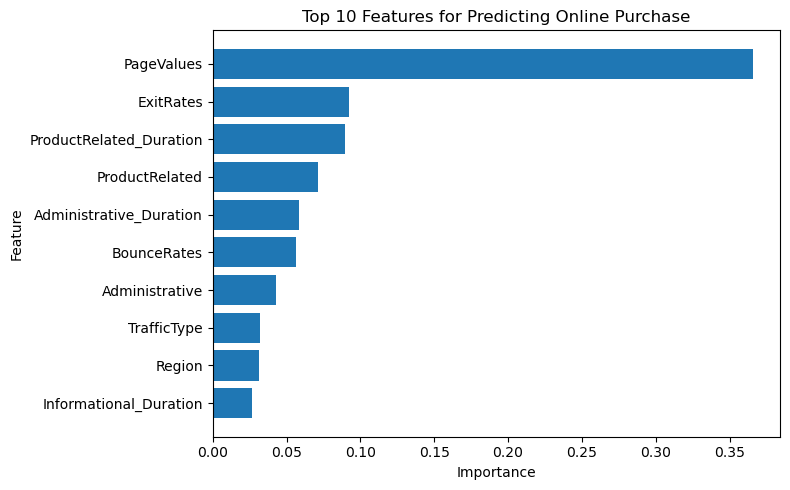

In [22]:
# Plot the top 10 Random Forest feature importances

top_rf = rf_importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Predicting Online Purchase")
plt.tight_layout()
plt.show()

In [23]:
# Compare the top features identified by both models

print("Top 10 Decision Tree features:")
print(dt_importance.head(10).to_string(index=False))

print("\nTop 10 Random Forest features:")
print(rf_importance.head(10).to_string(index=False))

Top 10 Decision Tree features:
                Feature  Importance
             PageValues    0.431413
ProductRelated_Duration    0.080329
              ExitRates    0.075316
            BounceRates    0.075066
         ProductRelated    0.064545
Administrative_Duration    0.054894
         Administrative    0.046002
            TrafficType    0.026003
                 Region    0.025134
 Informational_Duration    0.024669

Top 10 Random Forest features:
                Feature  Importance
             PageValues    0.365884
              ExitRates    0.091978
ProductRelated_Duration    0.089247
         ProductRelated    0.071022
Administrative_Duration    0.058222
            BounceRates    0.056087
         Administrative    0.042522
            TrafficType    0.031882
                 Region    0.031162
 Informational_Duration    0.026272


<Figure size 500x400 with 0 Axes>

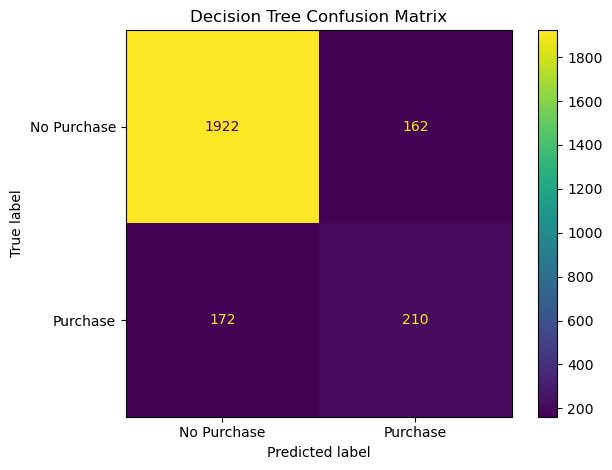

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

# Decision Tree confusion matrix
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=["No Purchase", "Purchase"]
)
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

<Figure size 500x400 with 0 Axes>

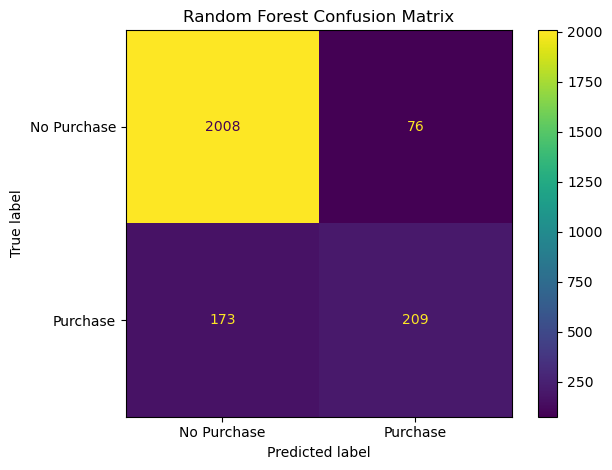

In [25]:
# Random Forest confusion matrix
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Purchase", "Purchase"]
)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [26]:
# Compare model performance

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1-score": [dt_f1, rf_f1],
    "ROC-AUC": [dt_roc_auc, rf_roc_auc]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.864558,0.564516,0.549738,0.557029,0.736002
1,Random Forest,0.899027,0.733333,0.547120,0.626687,0.918365


<Figure size 700x500 with 0 Axes>

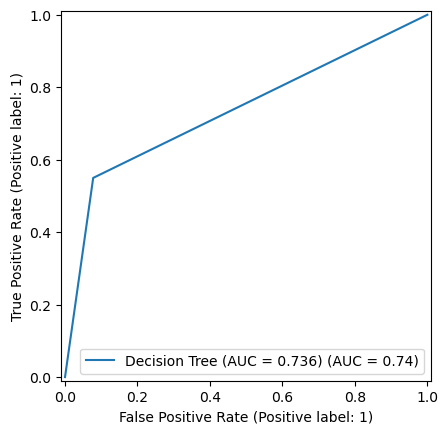

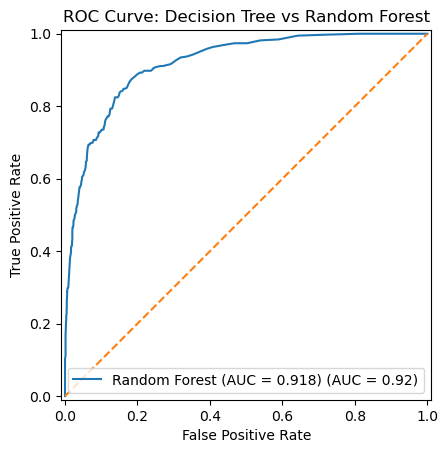

In [27]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name=f"Decision Tree (AUC = {dt_roc_auc:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve: Decision Tree vs Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## Dataset 2: Online Retail II

In [28]:
# Load the Online Retail II dataset

retail_df = pd.read_excel("online_retail_II.xlsx")

print("Dataset loaded successfully.")
print("Shape:", retail_df.shape)

Dataset loaded successfully.
Shape: (525461, 8)


In [30]:
# Inspect the Online Retail II dataset

print("Column names:")
print(retail_df.columns.tolist())

print("\nFirst 5 rows:")
display(retail_df.head())

print("\nDataset information:")
retail_df.info()

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [31]:
# Check missing values

print("Missing values:")
print(retail_df.isnull().sum())

print("\nDuplicate rows:")
print(retail_df.duplicated().sum())

Missing values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Duplicate rows:
6865


In [32]:
# Check transaction values and potential cancellations

print("Quantity statistics:")
print(retail_df["Quantity"].describe())

print("\nPrice statistics:")
print(retail_df["Price"].describe())

print("\nInvoices starting with 'C' (potential cancellations):")
print(retail_df["Invoice"].astype(str).str.startswith("C").sum())

print("\nTransactions with zero or negative quantity:")
print((retail_df["Quantity"] <= 0).sum())

print("\nTransactions with zero or negative price:")
print((retail_df["Price"] <= 0).sum())

Quantity statistics:
count    525461.000000
mean         10.337667
std         107.424110
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: Quantity, dtype: float64

Price statistics:
count    525461.000000
mean          4.688834
std         146.126914
min      -53594.360000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64

Invoices starting with 'C' (potential cancellations):
10206

Transactions with zero or negative quantity:
12326

Transactions with zero or negative price:
3690


In [33]:
# Understand the coverage of the Online Retail II dataset

print("Date range:")
print("Start:", retail_df["InvoiceDate"].min())
print("End:", retail_df["InvoiceDate"].max())

print("\nUnique customers:")
print(retail_df["Customer ID"].nunique())

print("\nUnique invoices:")
print(retail_df["Invoice"].nunique())

print("\nUnique products:")
print(retail_df["StockCode"].nunique())

print("\nUnique countries:")
print(retail_df["Country"].nunique())

print("\nTop 10 countries:")
print(retail_df["Country"].value_counts().head(10))

Date range:
Start: 2009-12-01 07:45:00
End: 2010-12-09 20:01:00

Unique customers:
4383

Unique invoices:
28816

Unique products:
4632

Unique countries:
40

Top 10 countries:
Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64


In [34]:
# Create a cleaned copy for customer-level analysis

retail_clean = retail_df.copy()

# Remove transactions without a Customer ID
retail_clean = retail_clean.dropna(subset=["Customer ID"])

# Keep only positive quantities
retail_clean = retail_clean[retail_clean["Quantity"] > 0]

# Keep only positive prices
retail_clean = retail_clean[retail_clean["Price"] > 0]

# Remove cancelled invoices
retail_clean = retail_clean[
    ~retail_clean["Invoice"].astype(str).str.startswith("C")
]

print("Original rows:", len(retail_df))
print("Cleaned rows:", len(retail_clean))
print("Rows removed:", len(retail_df) - len(retail_clean))

Original rows: 525461
Cleaned rows: 407664
Rows removed: 117797


In [35]:
# Calculate revenue for each transaction

retail_clean["Revenue"] = (
    retail_clean["Quantity"] * retail_clean["Price"]
)

print("Revenue calculated successfully.")

print("\nRevenue statistics:")
print(retail_clean["Revenue"].describe())

print("\nFirst 5 transactions with revenue:")
display(
    retail_clean[
        ["Invoice", "Quantity", "Price", "Revenue", "Customer ID"]
    ].head()
)

Revenue calculated successfully.

Revenue statistics:
count    407664.000000
mean         21.664909
std          77.150058
min           0.001000
25%           4.950000
50%          11.900000
75%          19.500000
max       15818.400000
Name: Revenue, dtype: float64

First 5 transactions with revenue:


,Invoice,Quantity,Price,Revenue,Customer ID
0,489434,12,6.95,83.4,13085.0
1,489434,12,6.75,81.0,13085.0
2,489434,12,6.75,81.0,13085.0
3,489434,48,2.10,100.8,13085.0
4,489434,24,1.25,30.0,13085.0


In [36]:
# Create customer-level features from Online Retail II

customer_df = retail_clean.groupby("Customer ID").agg(
    TotalRevenue=("Revenue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueInvoices=("Invoice", "nunique"),
    UniqueProducts=("StockCode", "nunique")
).reset_index()

# Calculate average transaction value
customer_df["AvgTransactionValue"] = (
    customer_df["TotalRevenue"] / customer_df["UniqueInvoices"]
)

# Display the first 5 customers
display(customer_df.head())

print("Number of customers:", len(customer_df))
print("Number of features:", len(customer_df.columns))

,Customer ID,TotalRevenue,TotalQuantity,UniqueInvoices,UniqueProducts,AvgTransactionValue
0,12346.0,372.86,70,11,26,33.896364
1,12347.0,1323.32,828,2,70,661.660000
2,12348.0,222.16,373,1,20,222.160000
3,12349.0,2671.14,993,3,90,890.380000
4,12351.0,300.93,261,1,21,300.930000


Number of customers: 4312
Number of features: 6


In [37]:
# Create target variable: High-Value Customer

revenue_threshold = customer_df["TotalRevenue"].quantile(0.75)

customer_df["HighValue"] = (
    customer_df["TotalRevenue"] >= revenue_threshold
).astype(int)

print("High-value customer threshold:", revenue_threshold)

print("\nCustomer class distribution:")
print(customer_df["HighValue"].value_counts())

print("\nClass proportions:")
print(customer_df["HighValue"].value_counts(normalize=True))

High-value customer threshold: 1723.1425

Customer class distribution:
HighValue
0    3234
1    1078
Name: count, dtype: int64

Class proportions:
HighValue
0    0.75
1    0.25
Name: proportion, dtype: float64


In [38]:
# Select features for machine learning
# TotalRevenue is excluded because HighValue was created from it.

features = [
    "TotalQuantity",
    "UniqueInvoices",
    "UniqueProducts",
    "AvgTransactionValue"
]

X = customer_df[features]
y = customer_df["HighValue"]

print("Features used:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
['TotalQuantity', 'UniqueInvoices', 'UniqueProducts', 'AvgTransactionValue']

X shape: (4312, 4)
y shape: (4312,)


In [39]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training set: (3449, 4)
Test set: (863, 4)

Training class distribution:
HighValue
0    0.750072
1    0.249928
Name: proportion, dtype: float64

Test class distribution:
HighValue
0    0.74971
1    0.25029
Name: proportion, dtype: float64


In [40]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Calculate evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

# Display results
print("Decision Tree Performance")
print("-" * 30)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance
------------------------------
Accuracy : 0.9479
Precision: 0.8834
Recall   : 0.9120
F1-score : 0.8975
ROC-AUC  : 0.9785

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       647
           1       0.88      0.91      0.90       216

    accuracy                           0.95       863
   macro avg       0.93      0.94      0.93       863
weighted avg       0.95      0.95      0.95       863



In [42]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [43]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-" * 30)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
------------------------------
Accuracy : 0.9838
Precision: 0.9633
Recall   : 0.9722
F1-score : 0.9677
ROC-AUC  : 0.9979

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       647
           1       0.96      0.97      0.97       216

    accuracy                           0.98       863
   macro avg       0.98      0.98      0.98       863
weighted avg       0.98      0.98      0.98       863



In [44]:
# Compare model performance

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1-score": [dt_f1, rf_f1],
    "ROC-AUC": [dt_roc_auc, rf_roc_auc]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.947856,0.883408,0.912037,0.897494,0.978526
1,Random Forest,0.983778,0.963303,0.972222,0.967742,0.997946


In [51]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest model for Dataset 2
rf_model_retail = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model_retail.fit(X_train, y_train)

print("Random Forest model for Dataset 2 trained successfully.")

Random Forest model for Dataset 2 trained successfully.


In [52]:
# Feature importance for Dataset 2

retail_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model_retail.feature_importances_
}).sort_values("Importance", ascending=False)

display(retail_feature_importance)

,Feature,Importance
0,TotalQuantity,0.506265
1,UniqueInvoices,0.258968
3,AvgTransactionValue,0.160806
2,UniqueProducts,0.073961


### Comparison of Machine Learning Insights Across the Two Datasets

| Dataset | Main ML Insight | Most Important Features |
|---|---|---|
| Online Shoppers Intention | Purchase intention is strongly related to customers' website browsing behaviour and the value of their session. | PageValues, ExitRates, ProductRelated_Duration |
| Online Retail II | High customer value is primarily associated with purchasing volume and transaction frequency. | TotalQuantity, UniqueInvoices, AvgTransactionValue |

### Model Evaluation Metrics

Five evaluation metrics were used to compare the Decision Tree and Random Forest models: Accuracy, Precision, Recall, F1-score and ROC-AUC.

- **Accuracy** measures the overall proportion of correctly classified observations. It provides a general measure of model performance.
- **Precision** measures how many customers predicted as the positive class were actually positive. This is important when the business wants to avoid incorrectly targeting customers as likely purchasers or high-value customers.
- **Recall** measures how many of the actual positive customers were correctly identified. This is important because failing to identify potential purchasers or high-value customers may result in missed business opportunities.
- **F1-score** provides a balance between Precision and Recall. It is particularly useful because the positive class represents a smaller proportion of observations in both classification tasks.
- **ROC-AUC** measures the model's ability to distinguish between the two classes across different classification thresholds. A higher ROC-AUC indicates better overall discriminatory ability.

Using multiple metrics provides a more complete assessment than Accuracy alone. In this case, Precision, Recall and F1-score are particularly useful because both case studies involve identifying commercially important positive outcomes, while ROC-AUC provides an additional measure of how well the models distinguish between the classes.

### Model Effectiveness

For both datasets, the Random Forest model outperformed the Decision Tree across all evaluation metrics.

For the Online Shoppers Intention dataset, the Random Forest achieved an Accuracy of approximately 89.9%, compared with 86.5% for the Decision Tree. Its ROC-AUC was also substantially higher (0.918 compared with 0.736), indicating that the Random Forest was considerably better at distinguishing between purchasing and non-purchasing sessions.

For the Online Retail II dataset, the Random Forest achieved an Accuracy of approximately 98.4%, compared with 94.8% for the Decision Tree. It also achieved higher Precision, Recall, F1-score and ROC-AUC, with a ROC-AUC of approximately 0.998.

Overall, the Random Forest provided the most effective classification performance for both datasets. Its consistently higher Precision, Recall, F1-score and ROC-AUC indicate that it was better suited to identifying commercially relevant customers than the single Decision Tree.